In [ ]:
# PravahAI
## IIT Kharagpur ML Hackathon

### Team Members
# Deep Raj
# Kripashankar Yadav
# Shikha Agnihotri
# Unnisha Sen

### Objective
# Predict the yield (%) of Product B in a continuous chemical reactor.

In [ ]:
# 1. Import Libraries

In [ ]:
# 2. Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/PravahAI")

train_df = pd.read_csv(DATA_PATH / "train_dataset.csv")
test_df = pd.read_csv(DATA_PATH / "test_dataset.csv")

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (150, 6)
Test Shape : (50, 5)


In [5]:
# 3. Data preprocessing
# - Missing Values
#- Data Types
#- Duplicate Rows
#- Basic Cleaning

In [6]:
print("Train dtypes:\n", train_df.dtypes)
print("\nTest dtypes:\n", test_df.dtypes)

# all columns should be numeric (float/int) — if any show as 'object', investigate

Train dtypes:
 flow_rate_L_min         float64
concentration_mol_L     float64
inlet_temperature_K     float64
length_m                float64
jacket_temperature_K    float64
overall_yield           float64
dtype: object

Test dtypes:
 flow_rate_L_min         float64
concentration_mol_L     float64
inlet_temperature_K     float64
length_m                float64
jacket_temperature_K    float64
dtype: object


In [7]:
#Check for missing values
print("Missing values in train:\n", train_df.isnull().sum())
print("\nMissing values in test:\n", test_df.isnull().sum())

Missing values in train:
 flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
overall_yield           0
dtype: int64

Missing values in test:
 flow_rate_L_min         0
concentration_mol_L     0
inlet_temperature_K     0
length_m                0
jacket_temperature_K    0
dtype: int64


In [8]:
# Check for duplicate rows
print("Duplicate rows in train:", train_df.duplicated().sum())
print("Duplicate rows in test :", test_df.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test : 0


In [9]:
# Domain sanity checks (physically impossible values)
feature_cols = ["flow_rate_L_min", "concentration_mol_L",
                 "inlet_temperature_K", "length_m", "jacket_temperature_K"]

for col in feature_cols:
    neg_count = (train_df[col] < 0).sum()
    if neg_count > 0:
        print(f"WARNING: {neg_count} negative values in {col}")
    else:
        print(f"{col}: OK (no negative values)")

# target should be between 0 and 100 (%)
out_of_range = train_df[(train_df["overall_yield"] < 0) | (train_df["overall_yield"] > 100)]
print(f"\nYield values outside [0,100]: {len(out_of_range)}")

flow_rate_L_min: OK (no negative values)
concentration_mol_L: OK (no negative values)
inlet_temperature_K: OK (no negative values)
length_m: OK (no negative values)
jacket_temperature_K: OK (no negative values)

Yield values outside [0,100]: 0


In [10]:
# Check min/max ranges of every column
print("Train ranges:")
print(train_df.describe().loc[["min", "max"]])

print("\nTest ranges:")
print(test_df.describe().loc[["min", "max"]])

# important: compare test min/max vs train min/max
# if test has values outside train's range, model will extrapolate (less reliable)

Train ranges:
     flow_rate_L_min  concentration_mol_L  inlet_temperature_K  length_m  \
min             5.41                 0.52               351.63      2.26   
max            79.02                 3.97               498.58     24.99   

     jacket_temperature_K  overall_yield  
min                354.01          0.000  
max                547.99         99.971  

Test ranges:
     flow_rate_L_min  concentration_mol_L  inlet_temperature_K  length_m  \
min             7.14                 0.55                353.5      2.03   
max            79.57                 3.91                498.1     24.83   

     jacket_temperature_K  
min                352.32  
max                546.53  


In [11]:
# Detect outliers using IQR (flag only, don't delete yet)
for col in feature_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (range kept: {lower:.2f} to {upper:.2f})")

# Note: don't auto-delete these. In physics/reactor data, extreme values
# are often real edge-case operating conditions, not data errors.

flow_rate_L_min: 0 outliers (range kept: -39.06 to 121.40)
concentration_mol_L: 0 outliers (range kept: -1.33 to 5.84)
inlet_temperature_K: 0 outliers (range kept: 273.68 to 576.55)
length_m: 0 outliers (range kept: -10.96 to 39.67)
jacket_temperature_K: 0 outliers (range kept: 254.05 to 625.46)


In [12]:
# 4. Exploratory Data Analysis (EDA)
# - Distribution
# - Correlation
# - Outliers
# - Target Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

feature_cols = ["flow_rate_L_min", "concentration_mol_L",
                 "inlet_temperature_K", "length_m", "jacket_temperature_K"]

In [15]:
# 4.1 Basic statistical summary
train_df.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


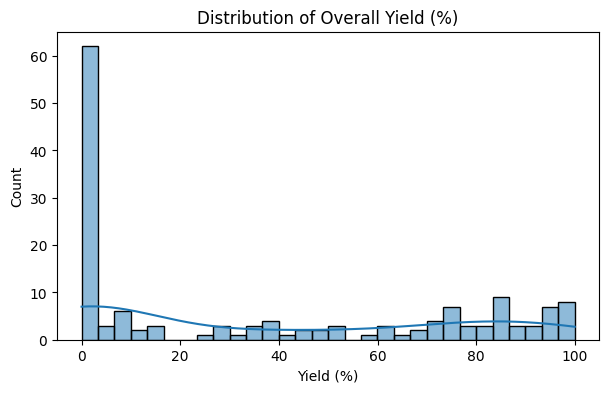

Rows with yield < 1%: 57 / 150 (38.0%)
Rows with yield > 99%: 4


In [18]:
# 4.2 Target Analysis - Distribution of overall_yield
plt.figure(figsize=(7, 4))
sns.histplot(train_df["overall_yield"], bins=30, kde=True)
plt.title("Distribution of Overall Yield (%)")
plt.xlabel("Yield (%)")
plt.ylabel("Count")
plt.show()

print(f"Rows with yield < 1%: {(train_df['overall_yield'] < 1).sum()} / {len(train_df)} "
      f"({(train_df['overall_yield'] < 1).mean()*100:.1f}%)")
print(f"Rows with yield > 99%: {(train_df['overall_yield'] > 99).sum()}")

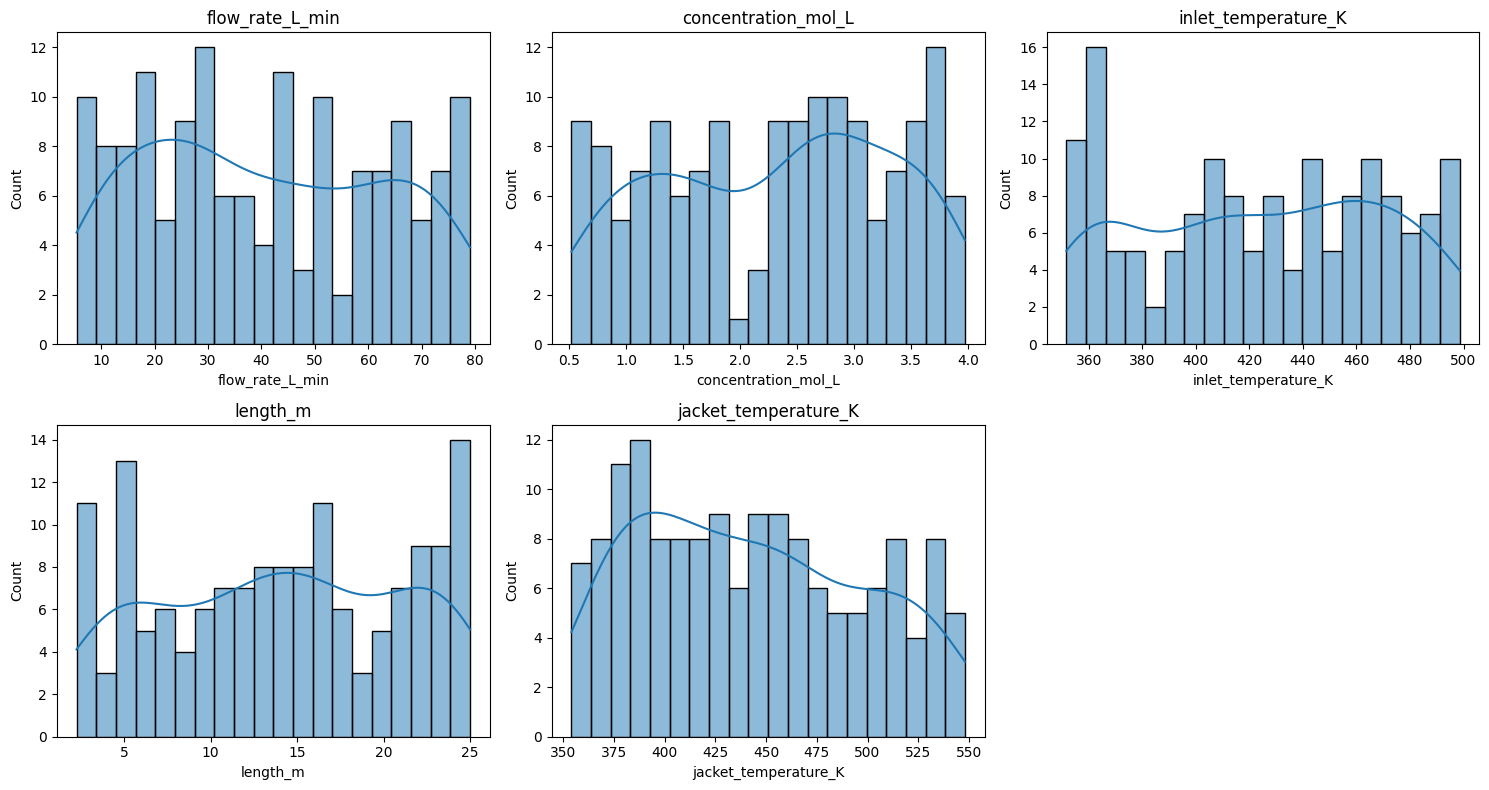

In [19]:
# 4.3 Distribution - individual feature histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.histplot(train_df[col], bins=20, kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

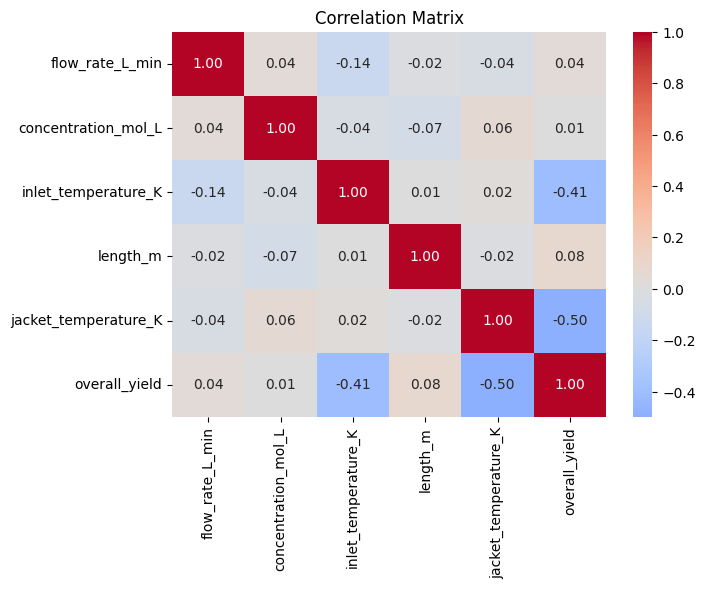

Correlation with yield, sorted:
overall_yield           1.000000
length_m                0.079985
flow_rate_L_min         0.038070
concentration_mol_L     0.008673
inlet_temperature_K    -0.405145
jacket_temperature_K   -0.498384
Name: overall_yield, dtype: float64


In [20]:
# 4.4 Correlation - heatmap + sorted correlation with target
plt.figure(figsize=(7, 5))
corr = train_df[feature_cols + ["overall_yield"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

print("Correlation with yield, sorted:")
print(corr["overall_yield"].sort_values(ascending=False))

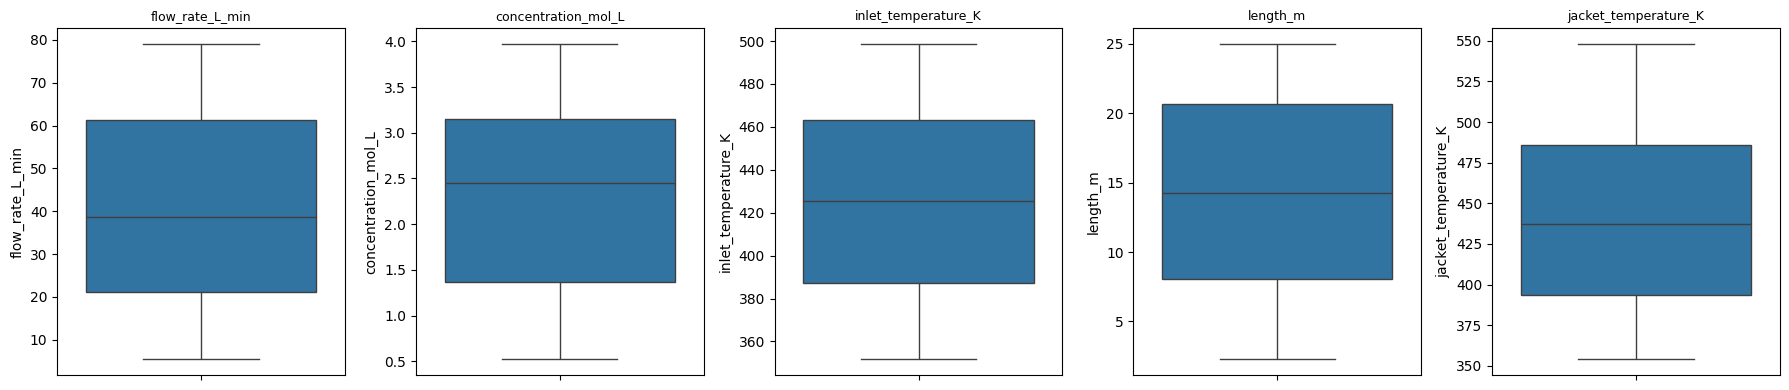

In [21]:
# 4.5 Outliers - boxplots
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, feature_cols):
    sns.boxplot(y=train_df[col], ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

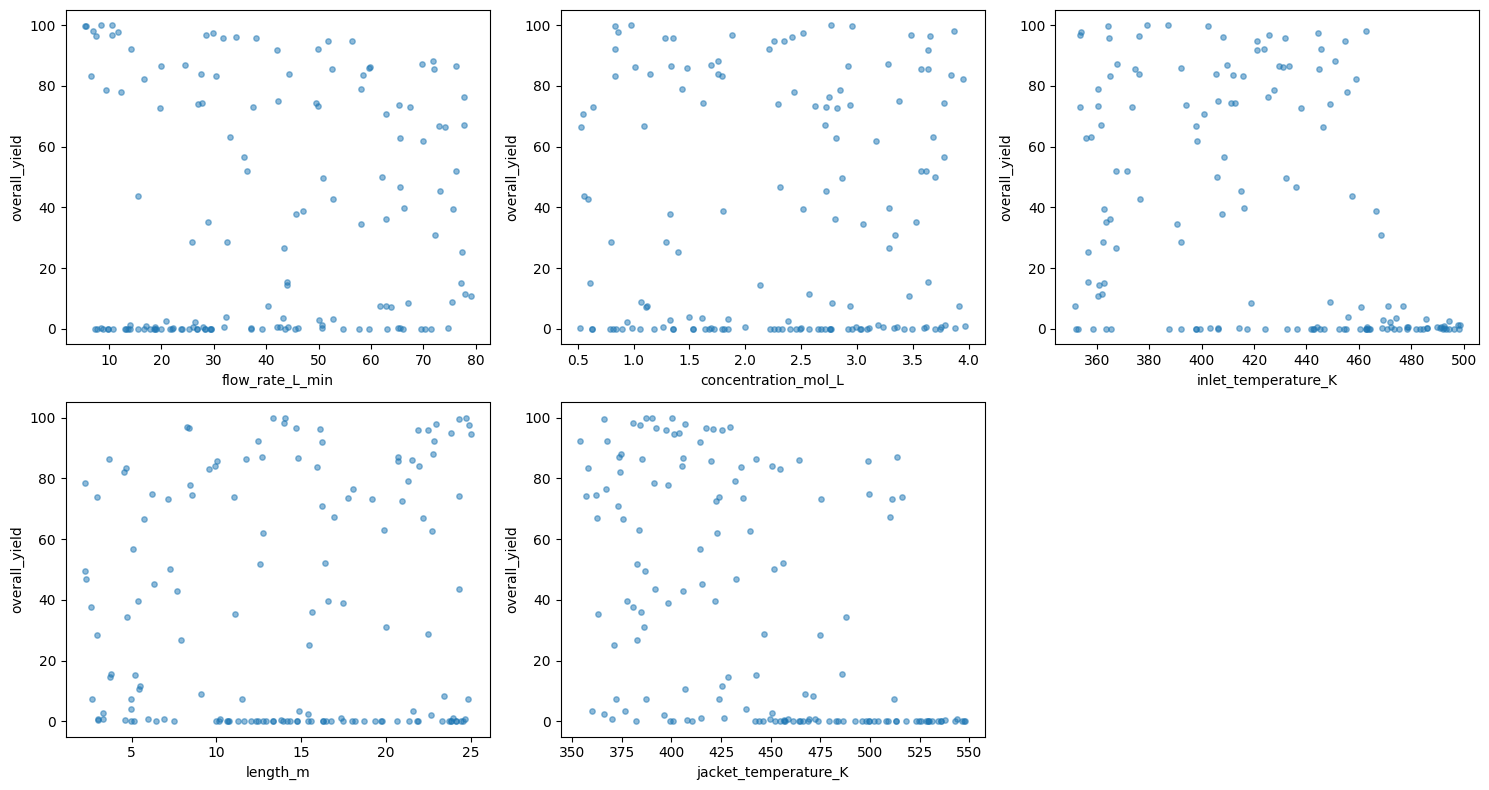

In [22]:
# 4.6 Feature vs Target relationship - scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    ax.scatter(train_df[col], train_df["overall_yield"], alpha=0.5, s=15)
    ax.set_xlabel(col)
    ax.set_ylabel("overall_yield")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

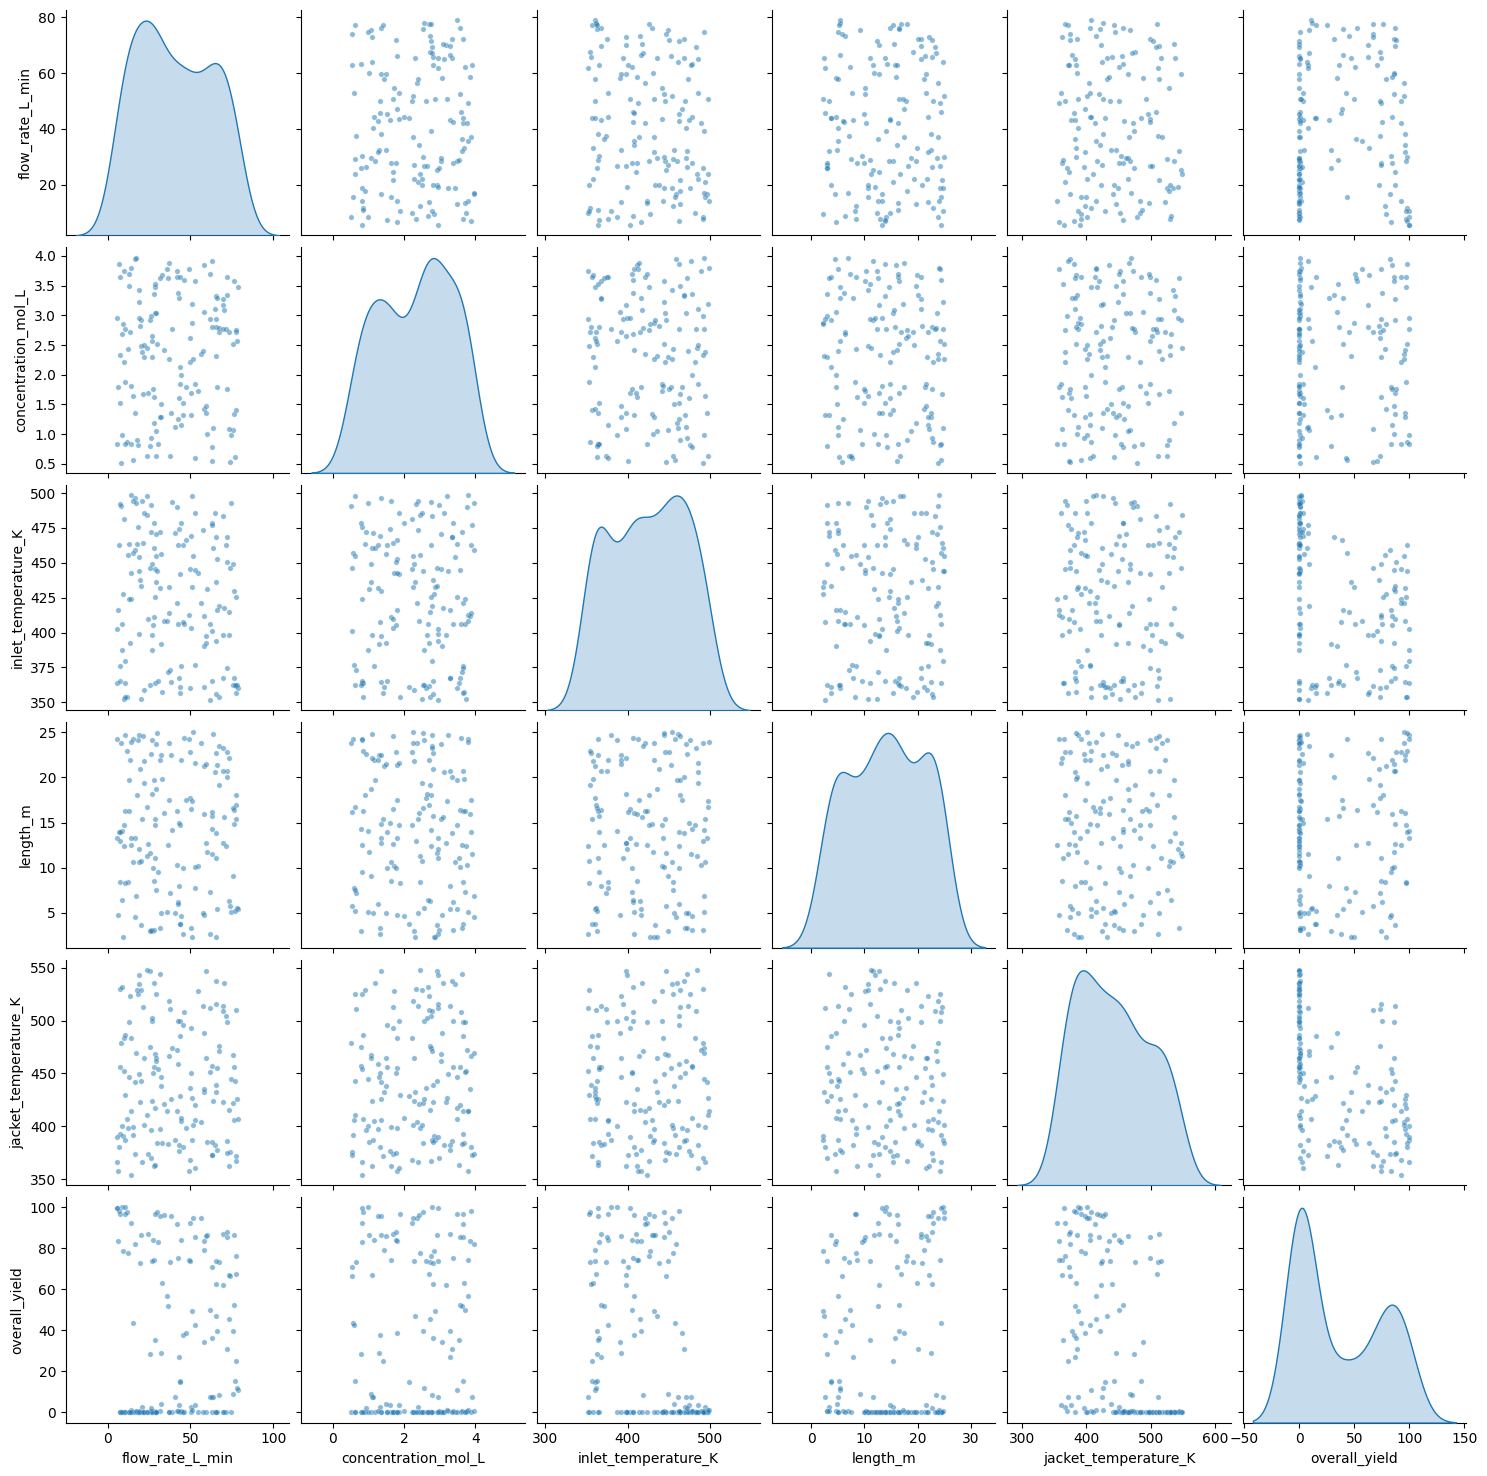

In [23]:
# 4.7 Pairplot - relationships between all features + target
sns.pairplot(train_df, vars=feature_cols + ["overall_yield"],
             diag_kind="kde", plot_kws={"alpha": 0.5, "s": 15})
plt.show()

# 5. Physics Based Feature Engineering
- Residence Time
- Temperature Difference
- Heat Exposure
- Flow × Concentration
- Polynomial Features
- Interaction Features

In [24]:
# Residence Time
train_df['residence_time'] = train_df['length_m'] / train_df['flow_rate_L_min']
test_df['residence_time'] = test_df['length_m'] / test_df['flow_rate_L_min']

# Temperature Difference
train_df['delta_T'] = train_df['jacket_temperature_K'] - train_df['inlet_temperature_K']
test_df['delta_T'] = test_df['jacket_temperature_K'] - test_df['inlet_temperature_K']

# Average Temperature (strongest single predictor found: -0.64 correlation)
train_df['avg_temp'] = (train_df['jacket_temperature_K'] + train_df['inlet_temperature_K']) / 2
test_df['avg_temp'] = (test_df['jacket_temperature_K'] + test_df['inlet_temperature_K']) / 2

# Flow x Concentration
train_df['flow_conc'] = train_df['flow_rate_L_min'] * train_df['concentration_mol_L']
test_df['flow_conc'] = test_df['flow_rate_L_min'] * test_df['concentration_mol_L']

# Heat Exposure (tested, kept for reference — weaker than temp_residence_interaction)
train_df['heat_exposure'] = train_df['residence_time'] * train_df['avg_temp']
test_df['heat_exposure'] = test_df['residence_time'] * test_df['avg_temp']

# Interaction / Threshold Features
train_df['is_high_temp'] = (train_df['avg_temp'] > 430).astype(int)
test_df['is_high_temp'] = (test_df['avg_temp'] > 430).astype(int)

train_df['temp_residence_interaction'] = train_df['residence_time'] * (430 - train_df['avg_temp'])
test_df['temp_residence_interaction'] = test_df['residence_time'] * (430 - test_df['avg_temp'])

print("New engineered columns added:")
print([c for c in train_df.columns if c not in ['flow_rate_L_min','concentration_mol_L','inlet_temperature_K','length_m','jacket_temperature_K','overall_yield']])

New engineered columns added:
['residence_time', 'delta_T', 'avg_temp', 'flow_conc', 'heat_exposure', 'is_high_temp', 'temp_residence_interaction']


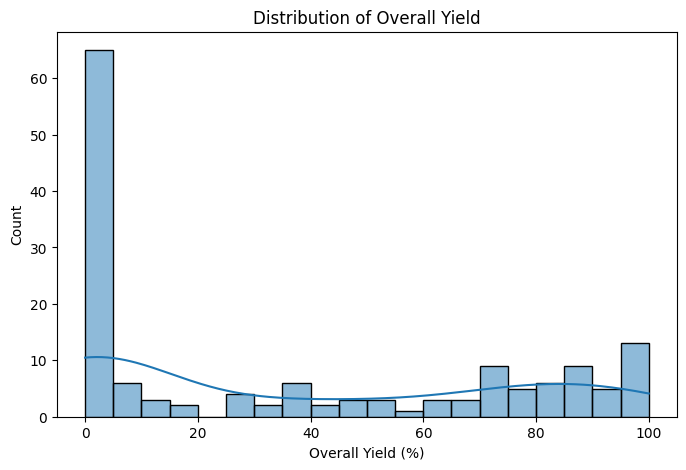

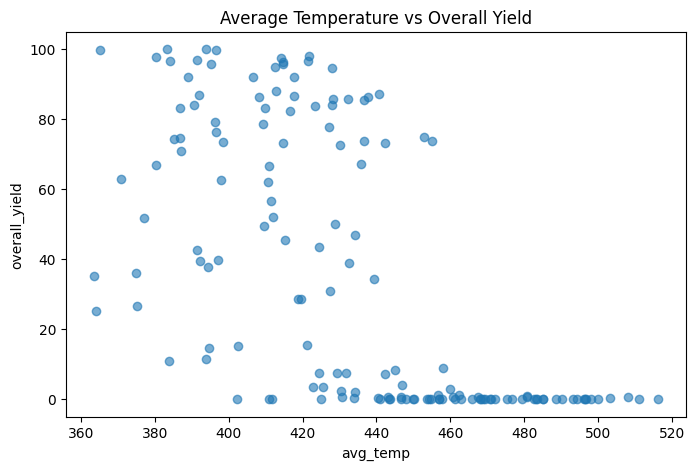

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of overall_yield — shows the bimodal pattern
plt.figure(figsize=(8,5))
sns.histplot(train_df['overall_yield'], bins=20, kde=True)
plt.title('Distribution of Overall Yield')
plt.xlabel('Overall Yield (%)')
plt.show()

# avg_temp vs yield — shows the temperature cliff
plt.figure(figsize=(8,5))
plt.scatter(train_df['avg_temp'], train_df['overall_yield'], alpha=0.6)
plt.xlabel('avg_temp')
plt.ylabel('overall_yield')
plt.title('Average Temperature vs Overall Yield')
plt.show()

In [27]:
# Correlation summary of engineered features vs overall_yield
feature_summary = pd.DataFrame({
    'feature': ['avg_temp', 'delta_T', 'residence_time', 'heat_exposure', 'is_high_temp', 'temp_residence_interaction'],
    'correlation_with_yield': [
        train_df['avg_temp'].corr(train_df['overall_yield']),
        train_df['delta_T'].corr(train_df['overall_yield']),
        train_df['residence_time'].corr(train_df['overall_yield']),
        train_df['heat_exposure'].corr(train_df['overall_yield']),
        train_df['is_high_temp'].corr(train_df['overall_yield']),
        train_df['temp_residence_interaction'].corr(train_df['overall_yield'])
    ],
    'notes': [
        'Strongest raw signal; clear cliff ~430K',
        'Weak; overall heat level matters more than the gap',
        'Weak alone (0.08), but 0.30 within safe-temp subgroup',
        'Diluted signal from combining with weak residence_time',
        'Binary flag for the temperature cliff',
        'Best combined feature; captures two-stage physics story'
    ]
})
feature_summary

,feature,correlation_with_yield,notes
0,avg_temp,-0.636739,Strongest raw signal; clear cliff ~430K
1,delta_T,-0.129203,Weak; overall heat level matters more than the...
2,residence_time,0.076424,"Weak alone (0.08), but 0.30 within safe-temp s..."
3,heat_exposure,0.003310,Diluted signal from combining with weak reside...
4,is_high_temp,-0.626467,Binary flag for the temperature cliff
5,temp_residence_interaction,0.507167,Best combined feature; captures two-stage phys...


**Feature engineering findings :**

- `avg_temp` is the strongest single predictor (correlation -0.64) — a clear yield "cliff"

  appears above ~430K, likely due to over-conversion of B into byproduct C

- `residence_time` is weak alone (0.08) but improves to 0.30 when restricted to rows below

  the temperature cliff — it matters once temperature isn't already the limiting factor

- `temp_residence_interaction` = residence_time × (430 - avg_temp) combines both effects

  into a single feature and is the strongest engineered predictor (correlation 0.51)

- `delta_T` and `heat_exposure` were tested but showed weak/diluted signal — kept for

  reference but not prioritized

In [28]:
# 6. Model Training
# - Random Forest (Baseline)
# - CatBoost
# - LightGBM
# - XGBoost
# - Extra Trees

In [29]:
# STEP 2: Prepare features and target

# Target variable
y = train_df["overall_yield"]

# Remove target from training data
X = train_df.drop(columns=["overall_yield"])

# Test data
X_test = test_df.copy()

print("Training features shape:", X.shape)
print("Target shape:", y.shape)
print("Test features shape:", X_test.shape)

print("\nFeatures:")
print(X.columns.tolist())

Training features shape: (150, 12)
Target shape: (150,)
Test features shape: (50, 12)

Features:
['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K', 'length_m', 'jacket_temperature_K', 'residence_time', 'delta_T', 'avg_temp', 'flow_conc', 'heat_exposure', 'is_high_temp', 'temp_residence_interaction']


In [30]:
# STEP 3: Train-Validation Split

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)

Training data: (120, 12)
Validation data: (30, 12)
Training target: (120,)
Validation target: (30,)


In [31]:
# STEP 4: Random Forest Baseline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Validation prediction
rf_pred = rf_model.predict(X_val)

# RMSE
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))

print("Random Forest Validation RMSE:", rf_rmse)

Random Forest Validation RMSE: 15.55651398769909


In [32]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00


In [33]:
# STEP 5: CatBoost Baseline

from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

# Train
cat_model.fit(X_train, y_train)

# Validation prediction
cat_pred = cat_model.predict(X_val)

# RMSE
cat_rmse = np.sqrt(mean_squared_error(y_val, cat_pred))

print("CatBoost Validation RMSE:", cat_rmse)

CatBoost Validation RMSE: 14.356708438312788


In [34]:
!pip install -q lightgbm

In [35]:
# STEP 6: LightGBM Baseline

from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

# Train
lgb_model.fit(X_train, y_train)

# Validation prediction
lgb_pred = lgb_model.predict(X_val)

# RMSE
lgb_rmse = np.sqrt(mean_squared_error(y_val, lgb_pred))

print("LightGBM Validation RMSE:", lgb_rmse)

LightGBM Validation RMSE: 13.856276362046998


In [36]:
!pip install -q xgboost

In [37]:
# STEP 7: XGBoost Baseline

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

# Train
xgb_model.fit(X_train, y_train)

# Validation prediction
xgb_pred = xgb_model.predict(X_val)

# RMSE
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred))

print("XGBoost Validation RMSE:", xgb_rmse)

XGBoost Validation RMSE: 12.944925807095874


In [38]:
# STEP 8: Extra Trees Baseline

from sklearn.ensemble import ExtraTreesRegressor

et_model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train
et_model.fit(X_train, y_train)

# Validation prediction
et_pred = et_model.predict(X_val)

# RMSE
et_rmse = np.sqrt(mean_squared_error(y_val, et_pred))

print("Extra Trees Validation RMSE:", et_rmse)

Extra Trees Validation RMSE: 17.908052104599378


In [39]:
# STEP 9: Model Comparison

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "CatBoost",
        "LightGBM",
        "XGBoost",
        "Extra Trees"
    ],
    "Validation RMSE": [
        rf_rmse,
        cat_rmse,
        lgb_rmse,
        xgb_rmse,
        et_rmse
    ]
})

results = results.sort_values("Validation RMSE").reset_index(drop=True)

print(results)

           Model  Validation RMSE
0        XGBoost        12.944926
1       LightGBM        13.856276
2       CatBoost        14.356708
3  Random Forest        15.556514
4    Extra Trees        17.908052


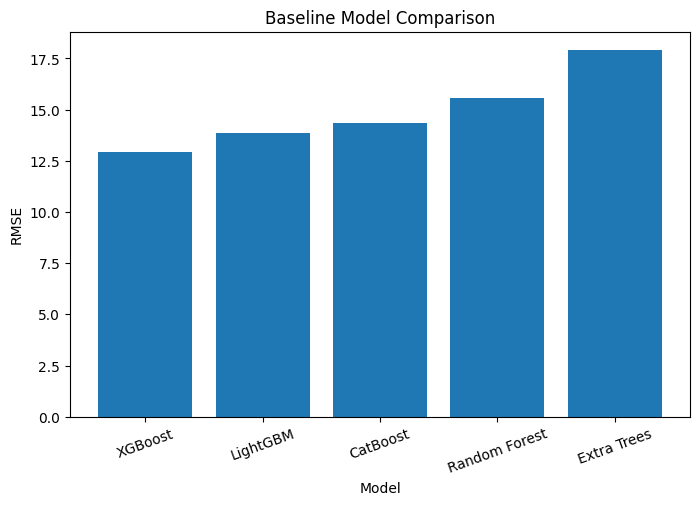

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Validation RMSE"])
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Baseline Model Comparison")
plt.xticks(rotation=20)
plt.show()

In [ ]:
# 7. Hyperparameter Tuning (Optuna)

In [41]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 21.0 MB/s eta 0:00:00


In [42]:
# STEP 11: Optuna + 5-Fold CV for XGBoost

import optuna
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBRegressor(**params)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse = -scores.mean()

    return rmse


study = optuna.create_study(
    direction="minimize",
    study_name="XGBoost_Optimization"
)

study.optimize(objective, n_trials=50)

print("Best CV RMSE:", study.best_value)
print("\nBest Parameters:")
print(study.best_params)

[I 2026-08-15 10:39:20,703] A new study created in memory with name: XGBoost_Optimization
[I 2026-08-15 10:39:33,788] Trial 0 finished with value: 18.09758237366068 and parameters: {'n_estimators': 623, 'learning_rate': 0.018628169227887258, 'max_depth': 7, 'min_child_weight': 7, 'subsample': 0.6616471721732383, 'colsample_bytree': 0.8317577196366756, 'reg_alpha': 2.580441785929064e-05, 'reg_lambda': 0.25653035311205313}. Best is trial 0 with value: 18.09758237366068.
[I 2026-08-15 10:39:35,495] Trial 1 finished with value: 18.090649437595165 and parameters: {'n_estimators': 550, 'learning_rate': 0.025008577668272955, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.7546148083057951, 'colsample_bytree': 0.6088934167025334, 'reg_alpha': 0.0027622058194685857, 'reg_lambda': 0.0010750422257010742}. Best is trial 1 with value: 18.090649437595165.
[I 2026-08-15 10:39:36,198] Trial 2 finished with value: 21.073417056857934 and parameters: {'n_estimators': 320, 'learning_rate': 0.0243460

Best CV RMSE: 16.653341786172923

Best Parameters:
{'n_estimators': 632, 'learning_rate': 0.0600664858649736, 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.8521803431945932, 'colsample_bytree': 0.9432403350138168, 'reg_alpha': 5.581010579156324e-06, 'reg_lambda': 5.500478503923325e-06}


In [43]:
# STEP 12: Fair 5-Fold CV Comparison

from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "CatBoost": cat_model,
    "LightGBM": lgb_model,
    "XGBoost": xgb_model
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse = -scores.mean()

    cv_results.append({
        "Model": name,
        "CV_RMSE": rmse
    })

cv_results = pd.DataFrame(cv_results)
cv_results = cv_results.sort_values("CV_RMSE").reset_index(drop=True)

print(cv_results)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


      Model    CV_RMSE
0  CatBoost  16.384614
1   XGBoost  17.752757
2  LightGBM  20.267434


In [44]:
# STEP 13: CatBoost Hyperparameter Tuning with 5-Fold CV

import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def objective_catboost(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 100, 800),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.15, log=True
        ),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg", 1, 10
        ),
        "random_strength": trial.suggest_float(
            "random_strength", 0, 2
        ),
        "loss_function": "RMSE",
        "verbose": False,
        "random_seed": 42
    }

    model = CatBoostRegressor(**params)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    return -scores.mean()


cat_study = optuna.create_study(
    direction="minimize",
    study_name="CatBoost_Optimization"
)

cat_study.optimize(
    objective_catboost,
    n_trials=50
)

print("Best CatBoost CV RMSE:", cat_study.best_value)
print("\nBest CatBoost Parameters:")
print(cat_study.best_params)

[I 2026-08-15 10:47:19,450] A new study created in memory with name: CatBoost_Optimization
[I 2026-08-15 10:47:26,087] Trial 0 finished with value: 17.690730124114314 and parameters: {'iterations': 595, 'learning_rate': 0.01619153472299613, 'depth': 5, 'l2_leaf_reg': 7.210460909186987, 'random_strength': 0.96199301891209}. Best is trial 0 with value: 17.690730124114314.
[I 2026-08-15 10:47:27,703] Trial 1 finished with value: 18.01521189066845 and parameters: {'iterations': 122, 'learning_rate': 0.03895989976386043, 'depth': 7, 'l2_leaf_reg': 2.790277917499123, 'random_strength': 0.9138178627085178}. Best is trial 0 with value: 17.690730124114314.
[I 2026-08-15 10:47:29,618] Trial 2 finished with value: 17.794767938767304 and parameters: {'iterations': 588, 'learning_rate': 0.023923448377838226, 'depth': 4, 'l2_leaf_reg': 9.043164041904099, 'random_strength': 1.000415887513382}. Best is trial 0 with value: 17.690730124114314.
[I 2026-08-15 10:47:36,331] Trial 3 finished with value: 16.

Best CatBoost CV RMSE: 14.976804769247531

Best CatBoost Parameters:
{'iterations': 435, 'learning_rate': 0.13181420564174412, 'depth': 7, 'l2_leaf_reg': 9.489454862552059, 'random_strength': 0.24385162800326637}


In [45]:
# STEP 14: Tuned CatBoost - 5-Fold Out-of-Fold Validation

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_pred = np.zeros(len(y))

for train_idx, val_idx in kf.split(X):

    X_tr = X.iloc[train_idx]
    X_va = X.iloc[val_idx]

    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]

    model = CatBoostRegressor(
        **cat_study.best_params,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )

    model.fit(X_tr, y_tr)

    oof_pred[val_idx] = model.predict(X_va)

# Overall OOF RMSE
cat_oof_rmse = np.sqrt(
    mean_squared_error(y, oof_pred)
)

print("Tuned CatBoost OOF RMSE:", cat_oof_rmse)

Tuned CatBoost OOF RMSE: 15.225616696578559


In [46]:
# STEP 15: CatBoost + XGBoost OOF Ensemble

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_oof = np.zeros(len(y))
xgb_oof = np.zeros(len(y))

# Best XGBoost parameters found by Optuna
xgb_best_params = study.best_params

for train_idx, val_idx in kf.split(X):

    X_tr = X.iloc[train_idx]
    X_va = X.iloc[val_idx]

    y_tr = y.iloc[train_idx]

    # ---------------- CATBOOST ----------------
    cat_model = CatBoostRegressor(
        **cat_study.best_params,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )

    cat_model.fit(X_tr, y_tr)

    cat_oof[val_idx] = cat_model.predict(X_va)

    # ---------------- XGBOOST ----------------
    xgb_model_tuned = XGBRegressor(
        **xgb_best_params,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_model_tuned.fit(X_tr, y_tr)

    xgb_oof[val_idx] = xgb_model_tuned.predict(X_va)


# Test different weights
weights = [0.70, 0.75, 0.80, 0.85, 0.90]

ensemble_results = []

for cat_weight in weights:

    xgb_weight = 1 - cat_weight

    ensemble_pred = (
        cat_weight * cat_oof +
        xgb_weight * xgb_oof
    )

    rmse = np.sqrt(
        mean_squared_error(y, ensemble_pred)
    )

    ensemble_results.append({
        "CatBoost Weight": cat_weight,
        "XGBoost Weight": xgb_weight,
        "OOF RMSE": rmse
    })


ensemble_results = pd.DataFrame(ensemble_results)

print(ensemble_results.sort_values("OOF RMSE"))

   CatBoost Weight  XGBoost Weight   OOF RMSE
2             0.80            0.20  15.099311
1             0.75            0.25  15.104318
3             0.85            0.15  15.108986
0             0.70            0.30  15.123993
4             0.90            0.10  15.133316


In [47]:
# STEP 16: Train Final Models on Full Training Data

from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# Final CatBoost
final_cat = CatBoostRegressor(
    **cat_study.best_params,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

final_cat.fit(X, y)


# Final XGBoost
final_xgb = XGBRegressor(
    **study.best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X, y)

print("Final CatBoost trained on:", X.shape)
print("Final XGBoost trained on:", X.shape)

Final CatBoost trained on: (150, 12)
Final XGBoost trained on: (150, 12)


In [48]:
# STEP 17: Predict Test Dataset

# CatBoost predictions
test_cat_pred = final_cat.predict(X_test)

# XGBoost predictions
test_xgb_pred = final_xgb.predict(X_test)

# 80% CatBoost + 20% XGBoost
final_predictions = (
    0.80 * test_cat_pred +
    0.20 * test_xgb_pred
)

print("Number of predictions:", len(final_predictions))

print("\nFirst 10 predictions:")
print(final_predictions[:10])

Number of predictions: 50

First 10 predictions:
[44.13375935 83.18795801  0.96939296 89.12458657  4.50246613 77.06195916
 83.53300183 77.01653438  7.37635083 61.83016931]


In [49]:
# STEP 18: Final Prediction Sanity Check

print("Number of predictions:", len(final_predictions))

print("NaN values:", np.isnan(final_predictions).sum())
print("Infinite values:", np.isinf(final_predictions).sum())

print("Minimum prediction:", final_predictions.min())
print("Maximum prediction:", final_predictions.max())
print("Mean prediction:", final_predictions.mean())

print("\nAll predictions:")
print(final_predictions)

Number of predictions: 50
NaN values: 0
Infinite values: 0
Minimum prediction: -2.55650294132891
Maximum prediction: 92.37635257519283
Mean prediction: 29.71582338997869

All predictions:
[ 4.41337593e+01  8.31879580e+01  9.69392955e-01  8.91245866e+01
  4.50246613e+00  7.70619592e+01  8.35330018e+01  7.70165344e+01
  7.37635083e+00  6.18301693e+01 -2.55650294e+00  1.09105923e-03
  4.31081094e+00  4.98904392e+01  6.84972996e+00  5.50907321e-02
  2.67439699e+00  1.04113172e+00  5.79661399e+00 -1.71247302e+00
  5.96315340e+01 -1.79991525e+00  1.38546912e+00  9.23763526e+01
  1.06313118e+01  2.65180025e+01  7.61501965e+01  3.34925714e+00
  8.26046033e+01  7.84090315e-01  8.15559365e+01  5.72373382e+01
  4.41512586e+01 -6.41910766e-01  1.81605234e+01  3.32393471e+01
  2.41455763e+01  5.92624223e+01 -8.01712649e-01  2.26156014e+01
 -1.90287408e-01  3.36457246e+01  1.15349790e+01  1.97616729e+00
  2.39039441e+01  8.53831690e+01  3.32313938e+00 -1.60412110e+00
  4.35584780e+01 -1.38181277e+00

In [50]:
# Check actual target range

print("Training target minimum:", y.min())
print("Training target maximum:", y.max())
print("Training target mean:", y.mean())

print("\nTraining target statistics:")
print(y.describe())

Training target minimum: 0.0
Training target maximum: 99.971
Training target mean: 36.22217333333333

Training target statistics:
count    150.000000
mean      36.222173
std       38.427427
min        0.000000
25%        0.013500
50%       15.314000
75%       74.876500
max       99.971000
Name: overall_yield, dtype: float64


In [51]:
# STEP 19: Clip predictions to valid yield range [0, 100]

final_predictions_clipped = np.clip(
    final_predictions,
    0,
    100
)

print("Minimum:", final_predictions_clipped.min())
print("Maximum:", final_predictions_clipped.max())
print("Number of predictions:", len(final_predictions_clipped))

Minimum: 0.0
Maximum: 92.37635257519283
Number of predictions: 50


In [ ]:
# 10. SHAP Explainability

In [52]:
!pip install -q shap

In [53]:
# STEP 19.5: SHAP Explainability

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for final CatBoost model
explainer = shap.TreeExplainer(final_cat)

# Calculate SHAP values on training data
shap_values = explainer.shap_values(X)

print("SHAP analysis completed.")
print("SHAP values shape:", shap_values.shape)

SHAP analysis completed.
SHAP values shape: (150, 12)


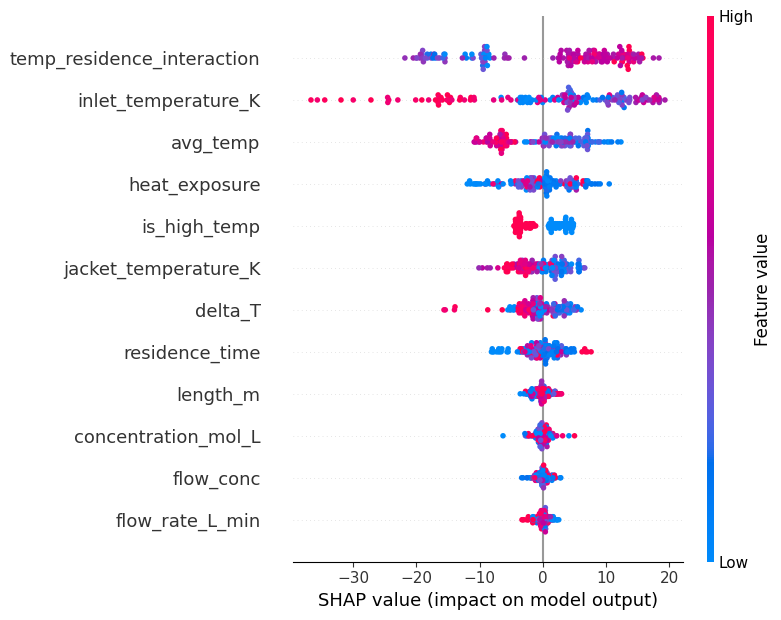

In [54]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X,
    show=True
)

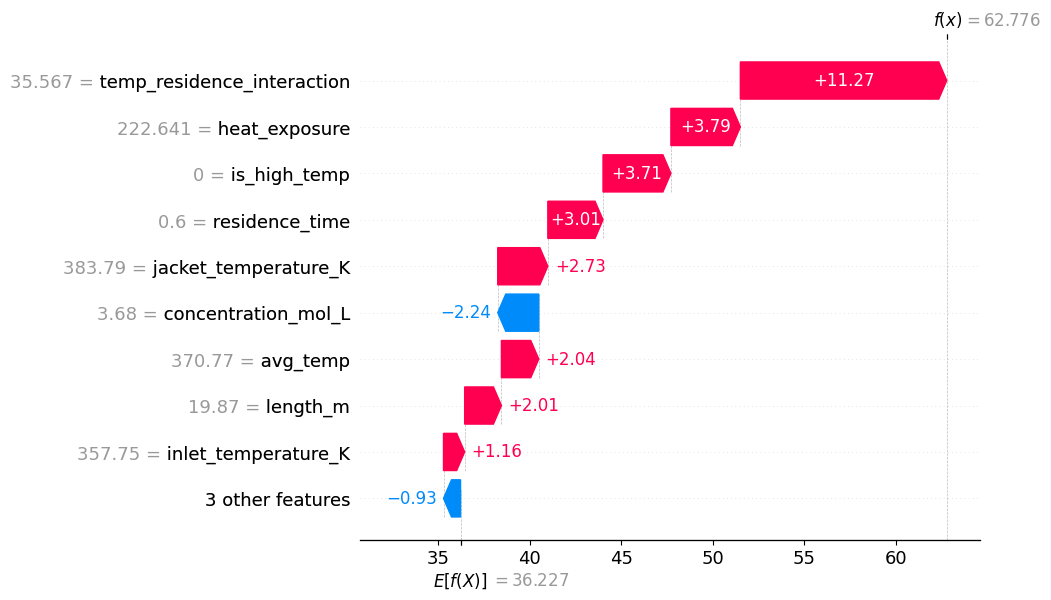

In [55]:
# Explain one sample prediction

sample_index = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X.iloc[sample_index],
        feature_names=X.columns
    )
)

**SHAP-based Interpretation:**

The SHAP analysis identifies temp_residence_interaction as the most influential engineered feature, indicating that temperature and residence time jointly affect the predicted reactor yield. This supports our physics-inspired feature engineering approach and provides an interpretable explanation of individual predictions.

In [57]:
# FINAL CHECK: Does clipping improve OOF RMSE?

ensemble_oof = (
    0.80 * cat_oof +
    0.20 * xgb_oof
)

rmse_before = np.sqrt(
    mean_squared_error(y, ensemble_oof)
)

ensemble_oof_clipped = np.clip(
    ensemble_oof,
    0,
    100
)

rmse_after = np.sqrt(
    mean_squared_error(y, ensemble_oof_clipped)
)

print("OOF RMSE before clipping:", rmse_before)
print("OOF RMSE after clipping :", rmse_after)

OOF RMSE before clipping: 15.099310565295797
OOF RMSE after clipping : 15.098193814122373


In [58]:
print(submission.shape)
print(submission.columns.tolist())
print("NaN:", submission.isna().sum().sum())
print("Min:", submission["overall_yield"].min())
print("Max:", submission["overall_yield"].max())
print(submission.head())

(50, 1)
['overall_yield']
NaN: 0
Min: 0.0
Max: 92.376
   overall_yield
0         44.134
1         83.188
2          0.969
3         89.125
4          4.502


## **Final Model & Submission Pipeline**

Our final predictive pipeline is designed as a physics-informed machine learning surrogate for reactor yield prediction.

```text
Training Dataset (150 samples)
            ↓
Exploratory Data Analysis
            ↓
Physics-Inspired Feature Engineering
            ↓
Model Comparison
(Random Forest, CatBoost, LightGBM, XGBoost, Extra Trees)
            ↓
5-Fold Cross-Validation
            ↓
Optuna Hyperparameter Optimization
            ↓
Tuned CatBoost + Tuned XGBoost
            ↓
80% CatBoost + 20% XGBoost Ensemble
            ↓
Out-of-Fold Validation
            ↓
Prediction Clipping to [0, 100]
            ↓
Train Final Models on Full Training Data
            ↓
Predict 50 Unseen Test Samples
            ↓
Round Predictions to 3 Decimal Places
            ↓
Final Submission: PravahAI.csv

In [60]:
# FINAL SUBMISSION CSV

submission = pd.DataFrame({
    "overall_yield": final_predictions_clipped
})

submission["overall_yield"] = submission["overall_yield"].round(3)

submission.to_csv("PravahAI.csv", index=False)

print("===== FINAL SUBMISSION CHECK =====")
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print("Rows:", len(submission))
print("\nFirst 10 rows:")
print(submission.head(10))
print("\nLast 5 rows:")
print(submission.tail(5))

print("\nFile created successfully: Dimethyl_Mercury.csv")

===== FINAL SUBMISSION CHECK =====
Shape: (50, 1)
Columns: ['overall_yield']
Rows: 50

First 10 rows:
   overall_yield
0         44.134
1         83.188
2          0.969
3         89.125
4          4.502
5         77.062
6         83.533
7         77.017
8          7.376
9         61.830

Last 5 rows:
    overall_yield
45         85.383
46          3.323
47          0.000
48         43.558
49          0.000

File created successfully: Dimethyl_Mercury.csv
